# LR Classifier on Raw Activations — Results Analysis

This notebook loads the outputs from `train_lr_classifier_streaming.py` and generates diagnostic plots across layers and granularities.

1. lr_classifier_results.json —
JSON keyed by layer number (e.g. "18", "19", …), with each layer containing metrics for each granularity.
- **Token-level metrics (evaluated on held-out shards, not cross-validated)**:
    - accuracy — fraction of correctly classified tokens on the test shards. A baseline sanity check, but can be misleading under class imbalance.
    -cauroc — area under the ROC curve, computed from clf.decision_function scores. This is the single most important metric for token-level because it's threshold-independent and insensitive to class imbalance. It tells you how well the linear classifier separates correct-reasoning tokens from incorrect-reasoning tokens in activation space.
    - f1 — harmonic mean of precision and recall at the default threshold (0). Useful because it penalizes both false positives and false negatives, but it's threshold-dependent so AUROC is more informative.
    - n_test, n_test_pos, n_test_neg — test set composition, so you can verify the class balance.
    - class_counts, class_weight_map — training class distribution and the balanced weights used during SGD, important for understanding whether the model was exposed to enough minority-class examples.
    - intercept, intercept_input_space — the learned bias term (in standardized space and projected back to input space).

- **Step-level and sample-level metrics (5-fold stratified cross-validation)**:
    - cv_roc_auc_mean / cv_roc_auc_std — the most important metric. The mean AUROC across folds tells you discriminative power; the std tells you how stable this estimate is. High std suggests the model's performance is sensitive to which data ends up in which fold, possibly due to few data points.
    - cv_accuracy_mean / cv_accuracy_std — same as above for accuracy.
    - cv_f1_mean / cv_f1_std — same for F1.
    - cv_precision_mean/std, cv_recall_mean/std — also stored, giving you the precision-recall trade-off.
    - Per-fold arrays (e.g. cv_roc_auc_folds, cv_roc_auc_train_folds) — the raw fold-by-fold values, critical for diagnosing variance and overfitting. If train-fold AUROC is much higher than test-fold AUROC, the model is overfitting.
    - n_samples, n_positive, n_negative — dataset size at this granularity.
    - n_iter / max_iter — number of LBFGS iterations the solver actually used vs the cap (2000). If n_iter == max_iter, the solver didn't converge and results may be unreliable.
    - cv_fit_time_mean/std, cv_score_time_mean/std — wall-clock timing.
    . scaler_mean_norm, scaler_var_mean — summary statistics of the StandardScaler, useful for sanity-checking that activations are in a reasonable range.

Weight vs reasoning direction comparisons (weight_vs_reasoning_vectors): cosine similarity between the learned LR weight vector (projected back to input space by dividing by scaler scales) and each pre-computed reasoning direction vector stored in the vectors file. This answers: "does the linear classifier find the same direction in activation space as the contrastive reasoning vector?" High cosine similarity (close to ±1) means the LR classifier independently rediscovered the same direction, providing strong validation. Low similarity means the supervised classifier found a different discriminative axis.

Cross-weight similarities (cross_weight_similarities): cosine similarities between weight vectors across granularities within the same layer (e.g. token_vs_step, token_vs_sample, step_vs_sample) and across layers within the same granularity. High cross-granularity similarity means all three levels of aggregation agree on the same discriminative direction — a strong consistency signal. High cross-layer similarity within a granularity means the separating hyperplane is stable across layers.

- Token-level: all reported metrics (accuracy, AUROC, F1) come from evaluating the SGD-trained model on the held-out test shards. There is no cross-validation — it's a single train/test split by shard.
- Step-level and sample-level: all reported metrics (cv_*_mean, cv_*_std, cv_*_folds) come exclusively from the cross_validate call, meaning they reflect test-fold performance averaged over the 5 stratified folds. The pipeline.fit(X, y) that follows on all data is only used to extract the weight vector and intercept for downstream analysis (cosine similarity with reasoning directions, weight sparsity plots, etc.) — it never contributes to any reported performance metric.

In [ ]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, auc,
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.constrained_layout.use': True,
})



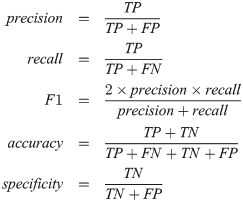

## 1 — Load all outputs

In [ ]:
# === SET THIS TO YOUR OUTPUT DIRECTORY ===
OUTPUT_DIR = Path("/home/ines/Reasoning-activations/results/lr_classifier_math_shepherd")

# JSON metrics
with open(OUTPUT_DIR / "lr_classifier_results.json") as f:
    results = json.load(f)

# Learned weight vectors
learned_weights = torch.load(OUTPUT_DIR / "lr_learned_weights.pt", weights_only=False)


PLOT_DIR = Path("/home/ines/Reasoning-activations/results/lr_classifier_math_shepherd/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Per-layer diagnostics
diag_dir = OUTPUT_DIR / "diagnostics"
diagnostics = {}
for p in sorted(diag_dir.glob("layer_*_diagnostics.pt")):
    layer_key = p.stem.split("_")[1]
    diagnostics[layer_key] = torch.load(p, weights_only=False)

# Determine layers (exclude non-layer keys)
layer_keys = sorted([k for k in results if k.isdigit()], key=int)
granularities = [g for g in ["token", "step", "sample"]
                 if g in results[layer_keys[0]]]

print(f"Layers      : {layer_keys}")
print(f"Granularities: {granularities}")
print(f"Diagnostics  : {sorted(diagnostics.keys())}")


## 2 — Performance across layers (Accuracy / AUROC / F1)

In [ ]:
metric_map = {
    "token":  {"accuracy": "accuracy",  "auroc": "auroc",  "f1": "f1"},
    "step":   {"accuracy": "cv_accuracy_mean", "auroc": "cv_roc_auc_mean", "f1": "cv_f1_mean"},
    "sample": {"accuracy": "cv_accuracy_mean", "auroc": "cv_roc_auc_mean", "f1": "cv_f1_mean"},
}
std_map = {
    "step":   {"accuracy": "cv_accuracy_std", "auroc": "cv_roc_auc_std", "f1": "cv_f1_std"},
    "sample": {"accuracy": "cv_accuracy_std", "auroc": "cv_roc_auc_std", "f1": "cv_f1_std"},
}

layers_int = [int(l) for l in layer_keys]
colors = {"token": "#1f77b4", "step": "#ff7f0e", "sample": "#2ca02c"}
markers = {"token": "o", "step": "s", "sample": "D"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, metric_name in zip(axes, ["accuracy", "auroc", "f1"]):
    for gran in granularities:
        vals, stds = [], []
        for lk in layer_keys:
            m = results[lk].get(gran, {})
            key = metric_map[gran][metric_name]
            vals.append(m.get(key, np.nan))
            if gran in std_map:
                stds.append(m.get(std_map[gran][metric_name], 0))
            else:
                stds.append(0)
        vals, stds = np.array(vals), np.array(stds)
        ax.plot(layers_int, vals, marker=markers[gran], label=gran,
                color=colors[gran], linewidth=1.8, markersize=5)
        if stds.any():
            ax.fill_between(layers_int, vals - stds, vals + stds,
                            alpha=0.15, color=colors[gran])
    ax.set_xlabel("Layer")
    ax.set_ylabel(metric_name.upper())
    ax.set_title(metric_name.upper() + " by Layer")
    ax.legend()
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.3)

fig.suptitle("Classification Performance across Layers", fontsize=14, y=1.02)
fig.savefig(PLOT_DIR / "performance_across_layers.png", dpi=150, bbox_inches="tight")
plt.show()

# Step/sample lines include shaded ±1 std bands from cross-validation.

## 3 — Token-level ROC & Precision-Recall curves

In [ ]:
if "token" in granularities:
    cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(layer_keys)))

    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5))

    for idx, lk in enumerate(layer_keys):
        diag = diagnostics.get(lk, {}).get("token")
        if diag is None:
            continue
        y_true = np.asarray(diag["y_true"])
        y_prob = np.asarray(diag["y_prob"])

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc_val = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, color=cmap[idx], linewidth=1.3,
                    label=f"L{lk} ({roc_auc_val:.3f})")

        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        pr_auc_val = auc(rec, prec)
        ax_pr.plot(rec, prec, color=cmap[idx], linewidth=1.3,
                   label=f"L{lk} ({pr_auc_val:.3f})")

    ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax_roc.set(xlabel="FPR", ylabel="TPR", title="Token-level ROC Curves")
    ax_roc.legend(fontsize=7, ncol=2)
    ax_roc.grid(True, alpha=0.3)

    ax_pr.set(xlabel="Recall", ylabel="Precision", title="Token-level Precision-Recall Curves")
    ax_pr.legend(fontsize=7, ncol=2)
    ax_pr.grid(True, alpha=0.3)
    fig.savefig(PLOT_DIR / "token_roc_pr_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Token granularity not available — skipping ROC/PR curves.")

## 4 — Token-level confusion matrix (best layer by AUROC)

In [ ]:
if "token" in granularities:
    best_layer = max(layer_keys,
                     key=lambda lk: results[lk]["token"].get("auroc", 0))
    diag = diagnostics[best_layer]["token"]
    y_true = np.asarray(diag["y_true"])
    y_pred = np.asarray(diag["y_pred"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    for ax, norm, title in [(ax1, None, "Counts"), (ax2, "true", "Normalized")]:
        cm = confusion_matrix(y_true, y_pred, normalize=norm)
        disp = ConfusionMatrixDisplay(cm, display_labels=["Incorrect", "Correct"])
        disp.plot(ax=ax, cmap="Blues", values_format=".0f" if norm is None else ".2f")
        ax.set_title(f"Layer {best_layer} — {title}")
    fig.suptitle(f"Token-level Confusion Matrix (best layer = {best_layer})",
                 fontsize=12, y=1.02)
    fig.savefig(PLOT_DIR / "token_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()

## 5 — CV fold variance (step & sample level)

In [ ]:
cv_grans = [g for g in ["step", "sample"] if g in granularities]

if cv_grans:
    fig, axes = plt.subplots(1, len(cv_grans), figsize=(6 * len(cv_grans), 5))
    if len(cv_grans) == 1:
        axes = [axes]

    for ax, gran in zip(axes, cv_grans):
        fold_data = []
        tick_labels = []
        for lk in layer_keys:
            folds = results[lk].get(gran, {}).get("cv_roc_auc_folds")
            if folds is not None:
                fold_data.append(folds)
                tick_labels.append(f"L{lk}")
        if fold_data:
            bp = ax.boxplot(fold_data, labels=tick_labels, patch_artist=True,
                            boxprops=dict(facecolor=colors[gran], alpha=0.4))
            ax.set_ylabel("AUROC")
            ax.set_title(f"{gran.capitalize()}-level CV AUROC (per fold)")
            ax.grid(True, alpha=0.3, axis='y')
    fig.savefig(PLOT_DIR / "cv_fold_variance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No CV granularities available.")

- each box showing the distribution of AUROC across the K folds for each layer. 
- This visualizes how stable the performance estimate is. 
- Wide boxes mean high variance, suggesting the metric is noisy (likely due to small dataset size at sample level). 
- Narrow boxes mean the AUROC estimate is robust. You're looking for tight boxes at high values.

## 6 — Train vs Test performance (overfitting diagnostic)

In [ ]:
if cv_grans:
    fig, axes = plt.subplots(1, len(cv_grans), figsize=(6 * len(cv_grans), 4.5))
    if len(cv_grans) == 1:
        axes = [axes]

    for ax, gran in zip(axes, cv_grans):
        train_vals, test_vals = [], []
        for lk in layer_keys:
            m = results[lk].get(gran, {})
            train_vals.append(m.get("cv_roc_auc_train_mean", np.nan))
            test_vals.append(m.get("cv_roc_auc_mean", np.nan))
        ax.plot(layers_int, train_vals, 's--', label="Train", color="#d62728", alpha=0.8)
        ax.plot(layers_int, test_vals, 'o-', label="Test", color=colors[gran])
        ax.fill_between(layers_int, test_vals, train_vals, alpha=0.1, color="#d62728")
        ax.set_xlabel("Layer")
        ax.set_ylabel("AUROC")
        ax.set_title(f"{gran.capitalize()}-level: Train vs Test AUROC")
        ax.legend()
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.grid(True, alpha=0.3)
    fig.savefig(PLOT_DIR / "train_vs_test_auroc.png", dpi=150, bbox_inches="tight")
    plt.show()

- A large shaded area means overfitting — the model memorizes the training set but doesn't generalize. ==> this is the case for the sample level
- regularization might be too weak for the sample level, where I  have "very few" data points relative to the 4096-dimensional feature space, making overfitting 
- For the sample level:
      - "n_samples": 3398,
      - "n_positive": 1177,
      - "n_negative": 2221,

## 7 — LR weights vs reasoning directions (cosine similarity)

In [ ]:
# Collect all reasoning-direction comparison data
cosine_data = {}  # {direction_name: {gran: [val_per_layer]}}

for gran in granularities:
    for lk in layer_keys:
        comps = results[lk].get(gran, {}).get("weight_vs_reasoning_vectors", {})
        for dname, cval in comps.items():
            cosine_data.setdefault(dname, {}).setdefault(gran, []).append(cval)

if cosine_data:
    n_dirs = len(cosine_data)
    fig, axes = plt.subplots(1, min(n_dirs, 4), figsize=(5 * min(n_dirs, 4), 4.5),
                             squeeze=False)
    axes = axes.ravel()

    for ax, (dname, gran_vals) in zip(axes, list(cosine_data.items())[:4]):
        for gran, vals in gran_vals.items():
            ax.plot(layers_int[:len(vals)], vals, marker=markers[gran],
                    color=colors[gran], label=gran, linewidth=1.5)
        ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
        ax.set_xlabel("Layer")
        ax.set_ylabel("Cosine Similarity")
        short_name = dname.replace('reasoning_direction_', '').replace('reasoning_direction', 'RD')
        ax.set_title(f"LR weight vs {short_name}")
        ax.legend()
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.grid(True, alpha=0.3)

    for ax in axes[len(cosine_data):]:
        ax.set_visible(False)
    fig.savefig(PLOT_DIR / "lr_weights_vs_reasoning_directions.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No reasoning-direction comparisons found in results.")

## 8 — Cross-granularity weight similarity heatmap (cosine similarity)

In [ ]:
cross_sims = results.get("cross_weight_similarities", {})

# Per-layer cross-granularity
per_layer_sims = {lk: cross_sims.get(lk, {}) for lk in layer_keys if lk in cross_sims}

if per_layer_sims:
    pair_names = sorted(set(p for d in per_layer_sims.values() for p in d))
    matrix = np.full((len(layer_keys), len(pair_names)), np.nan)
    for i, lk in enumerate(layer_keys):
        for j, pn in enumerate(pair_names):
            matrix[i, j] = per_layer_sims.get(lk, {}).get(pn, np.nan)

    fig, ax = plt.subplots(figsize=(max(4, len(pair_names) * 1.5), max(4, len(layer_keys) * 0.45)))
    im = ax.imshow(matrix, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(pair_names)))
    ax.set_xticklabels([p.replace('_vs_', ' vs ') for p in pair_names], rotation=30, ha='right')
    ax.set_yticks(range(len(layer_keys)))
    ax.set_yticklabels([f"Layer {l}" for l in layer_keys])
    plt.colorbar(im, ax=ax, label="Cosine Similarity")
    ax.set_title("Cross-Granularity Weight Cosine Similarity")
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            if not np.isnan(matrix[i, j]):
                ax.text(j, i, f"{matrix[i,j]:.2f}", ha='center', va='center', fontsize=8)
    fig.savefig(PLOT_DIR / "cross_granularity_weight_similarity.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No cross-granularity similarity data.")

## 9 — Cross-layer weight similarity (within each granularity)

In [ ]:
cross_layer_keys = [k for k in cross_sims if k.startswith("cross_layer_")]

if cross_layer_keys:
    fig, axes = plt.subplots(1, len(cross_layer_keys),
                             figsize=(6 * len(cross_layer_keys), 5), squeeze=False)
    axes = axes.ravel()

    for ax, clk in zip(axes, sorted(cross_layer_keys)):
        pairs = cross_sims[clk]
        n = len(layer_keys)
        mat = np.eye(n)
        layer_to_idx = {l: i for i, l in enumerate(layer_keys)}

        for pair_name, cosval in pairs.items():
            # parse "layer18_vs_layer19"
            parts = pair_name.replace("layer", "").split("_vs_")
            if len(parts) == 2 and parts[0] in layer_to_idx and parts[1] in layer_to_idx:
                i, j = layer_to_idx[parts[0]], layer_to_idx[parts[1]]
                mat[i, j] = mat[j, i] = cosval

        im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_xticks(range(n))
        ax.set_xticklabels([f"L{l}" for l in layer_keys], rotation=45)
        ax.set_yticks(range(n))
        ax.set_yticklabels([f"L{l}" for l in layer_keys])
        gran_name = clk.replace("cross_layer_", "")
        ax.set_title(f"Cross-Layer Similarity ({gran_name})")
        plt.colorbar(im, ax=ax, shrink=0.8)
        for i in range(n):
            for j in range(n):
                ax.text(j, i, f"{mat[i,j]:.2f}", ha='center', va='center', fontsize=6)
    fig.savefig(PLOT_DIR / "cross_layer_weight_similarity.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No cross-layer similarity data (need ≥2 layers).")

## 10 — Weight vector magnitude & sparsity across layers

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for gran in granularities:
    norms, ginis = [], []
    for lk in layer_keys:
        w = learned_weights.get(lk, {}).get(gran)
        if w is None:
            norms.append(np.nan); ginis.append(np.nan)
            continue
        w_np = w.numpy()
        norms.append(float(np.linalg.norm(w_np)))
        # Gini coefficient as sparsity measure
        abs_w = np.sort(np.abs(w_np))
        n = len(abs_w)
        gini = (2 * np.sum((np.arange(1, n+1)) * abs_w) / (n * abs_w.sum()) - (n+1)/n) if abs_w.sum() > 0 else 0
        ginis.append(gini)

    ax1.plot(layers_int, norms, marker=markers[gran], color=colors[gran],
             label=gran, linewidth=1.5)
    ax2.plot(layers_int, ginis, marker=markers[gran], color=colors[gran],
             label=gran, linewidth=1.5)

ax1.set(xlabel="Layer", ylabel="L2 Norm", title="Weight Vector Magnitude")
ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax2.set(xlabel="Layer", ylabel="Gini Coefficient", title="Weight Sparsity (higher = sparser)")
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.savefig(PLOT_DIR / "weight_magnitude_sparsity.png", dpi=150, bbox_inches="tight")
plt.show()

 L2 norm of the weight vector across layers (left), and Gini coefficient of absolute weights across layers (right). The L2 norm tells you how "confident" the classifier is — larger norms mean it pushes predictions further from the boundary. The Gini coefficient measures sparsity: a high Gini means a few features dominate the decision, while a low Gini means the classifier spreads weight across many dimensions. A sparse classifier is more interpretable but might indicate it's latching onto a few specific neurons rather than a distributed representation.

## 11 — Top-k feature weights (best layer)

In [ ]:
TOP_K = 30

# Pick best layer by sample-level AUROC if available, else step, else token
best_gran = "sample" if "sample" in granularities else ("step" if "step" in granularities else "token")
if best_gran == "token":
    best_lk = max(layer_keys, key=lambda lk: results[lk]["token"].get("auroc", 0))
else:
    best_lk = max(layer_keys, key=lambda lk: results[lk][best_gran].get("cv_roc_auc_mean", 0))

w = learned_weights[best_lk][best_gran].numpy()
top_pos = np.argsort(w)[-TOP_K:][::-1]
top_neg = np.argsort(w)[:TOP_K]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

ax1.barh(range(TOP_K), w[top_pos][::-1], color='#2ca02c', alpha=0.8)
ax1.set_yticks(range(TOP_K))
ax1.set_yticklabels([str(d) for d in top_pos[::-1]], fontsize=7)
ax1.set_xlabel("Weight")
ax1.set_title(f"Top {TOP_K} positive features\n(Layer {best_lk}, {best_gran})")

ax2.barh(range(TOP_K), w[top_neg][::-1], color='#d62728', alpha=0.8)
ax2.set_yticks(range(TOP_K))
ax2.set_yticklabels([str(d) for d in top_neg[::-1]], fontsize=7)
ax2.set_xlabel("Weight")
ax2.set_title(f"Top {TOP_K} negative features\n(Layer {best_lk}, {best_gran})")
fig.savefig(PLOT_DIR / "top_k_feature_weights.png", dpi=150, bbox_inches="tight")
plt.show()

## 12 — Weight distribution histogram (best layer, all granularities)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

for gran in granularities:
    w = learned_weights.get(best_lk, {}).get(gran)
    if w is not None:
        ax.hist(w.numpy(), bins=100, alpha=0.45, label=gran, color=colors[gran],
                density=True)

ax.set_xlabel("Weight value (input-space)")
ax.set_ylabel("Density")
ax.set_title(f"Weight Distribution — Layer {best_lk}")
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig(PLOT_DIR / "weight_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 13 — Convergence & timing diagnostics

In [ ]:
if cv_grans:
    print(f"{'Layer':<8} {'Gran':<8} {'n_iter':<8} {'max_iter':<10} {'fit_time (s)':<14} {'score_time (s)'}")
    print("-" * 65)
    for lk in layer_keys:
        for gran in cv_grans:
            m = results[lk].get(gran, {})
            n_it = m.get("n_iter", "?")
            mx_it = m.get("max_iter", "?")
            ft = m.get("cv_fit_time_mean", 0)
            st = m.get("cv_score_time_mean", 0)
            flag = "  ⚠️ CONVERGE" if isinstance(n_it, int) and isinstance(mx_it, int) and n_it >= mx_it else ""
            print(f"{lk:<8} {gran:<8} {str(n_it):<8} {str(mx_it):<10} {ft:<14.3f} {st:.3f}{flag}")

## 14 — Summary table

In [ ]:
print(f"{'Layer':<8}", end="")
for gran in granularities:
    print(f"{'| ' + gran + ' ACC':<16}{'AUROC':<10}{'F1':<10}", end="")
print()
print("-" * (8 + 36 * len(granularities)))

for lk in layer_keys:
    print(f"{lk:<8}", end="")
    for gran in granularities:
        m = results[lk].get(gran, {})
        if gran == "token":
            acc = m.get("accuracy", np.nan)
            aur = m.get("auroc", np.nan)
            f1  = m.get("f1", np.nan)
        else:
            acc = m.get("cv_accuracy_mean", np.nan)
            aur = m.get("cv_roc_auc_mean", np.nan)
            f1  = m.get("cv_f1_mean", np.nan)
        print(f"| {acc:<14.4f}{aur:<10.4f}{f1:<10.4f}", end="")
    print()

# STEP vs SAMPLE LR VECTOR COMPARISON

In [ ]:
# --- Build aligned arrays of step and sample weight vectors ---
step_vecs   = {}   # layer_key (str) -> np.ndarray  (d_model,)
sample_vecs = {}

for lk in layer_keys:
    w_step   = learned_weights.get(lk, {}).get("step")
    w_sample = learned_weights.get(lk, {}).get("sample")
    if w_step is not None:
        step_vecs[lk]   = w_step.numpy().astype(np.float32)
    if w_sample is not None:
        sample_vecs[lk] = w_sample.numpy().astype(np.float32)

common_layers = sorted(
    [lk for lk in layer_keys if lk in step_vecs and lk in sample_vecs],
    key=int
)
common_layers_int = [int(lk) for lk in common_layers]

print(f"Layers with both step and sample vectors: {common_layers}")
print(f"Vector dimension: {next(iter(step_vecs.values())).shape[0]:,}")

In [ ]:
import torch
import torch.nn.functional as F

cos_sims = []
for lk in common_layers:
    ws = torch.tensor(step_vecs[lk])
    wsa = torch.tensor(sample_vecs[lk])
    cos = F.cosine_similarity(ws.unsqueeze(0), wsa.unsqueeze(0)).item()
    cos_sims.append(cos)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(common_layers_int, cos_sims, 'o-', color="#9467bd", linewidth=2, markersize=7)
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
ax.axhline(1, color="green", linestyle="--", linewidth=1, alpha=0.5, label="Perfect alignment")
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title("Step vs Sample LR Vector — Cosine Similarity per Layer")
ax.set_xticks(common_layers_int)
ax.set_ylim(-0.1, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
for lk, cs in zip(common_layers_int, cos_sims):
    ax.annotate(f"{cs:.3f}", (lk, cs), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)
fig.savefig(PLOT_DIR / "step_vs_sample_cosine_sim.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCosine similarity (step vs sample) per layer:")
for lk, cs in zip(common_layers, cos_sims):
    bar = "█" * int(abs(cs) * 20)
    print(f"  Layer {lk}: {cs:+.4f}  {bar}")

In [ ]:
step_norms   = [np.linalg.norm(step_vecs[lk])   for lk in common_layers]
sample_norms = [np.linalg.norm(sample_vecs[lk]) for lk in common_layers]
norm_ratios  = [sn / (smn + 1e-12) for sn, smn in zip(step_norms, sample_norms)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(common_layers_int, step_norms,   'o-', color="#ff7f0e", label="step",   linewidth=2, markersize=6)
ax.plot(common_layers_int, sample_norms, 's-', color="#2ca02c", label="sample", linewidth=2, markersize=6)
ax.set_xlabel("Layer"); ax.set_ylabel("L2 norm")
ax.set_title("Weight Vector L2 Norm per Layer")
ax.set_xticks(common_layers_int); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(common_layers_int, norm_ratios, 'D-', color="#9467bd", linewidth=2, markersize=6)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="equal norms")
ax.set_xlabel("Layer"); ax.set_ylabel("||w_step|| / ||w_sample||")
ax.set_title("Norm Ratio: Step / Sample")
ax.set_xticks(common_layers_int); ax.legend(); ax.grid(True, alpha=0.3)

fig.suptitle("Step vs Sample — Weight Vector Norms", fontsize=13, fontweight="bold")
fig.savefig(PLOT_DIR / "step_vs_sample_norms.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Pick one representative layer (best step AUROC) for per-dim analysis
best_step_lk = max(common_layers, key=lambda lk: results[lk].get("step", {}).get("cv_roc_auc_mean", 0))
ws_best   = step_vecs[best_step_lk]
wsa_best  = sample_vecs[best_step_lk]

diff       = ws_best - wsa_best           # signed difference
abs_diff   = np.abs(diff)
d_model    = len(ws_best)
dims       = np.arange(d_model)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

ax = axes[0]
ax.plot(dims, ws_best,  color="#ff7f0e", alpha=0.6, linewidth=0.4, label="step")
ax.plot(dims, wsa_best, color="#2ca02c", alpha=0.6, linewidth=0.4, label="sample")
ax.set_ylabel("Weight"); ax.set_title(f"Layer {best_step_lk} — Weight values per dimension")
ax.legend(loc="upper right"); ax.grid(True, alpha=0.2)

ax = axes[1]
ax.plot(dims, diff, color="#9467bd", linewidth=0.4, alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("step − sample"); ax.set_title(f"Layer {best_step_lk} — Signed difference (step − sample)")
ax.grid(True, alpha=0.2)

ax = axes[2]
ax.plot(dims, abs_diff, color="#d62728", linewidth=0.4, alpha=0.8)
ax.set_xlabel("Dimension index"); ax.set_ylabel("|step − sample|")
ax.set_title(f"Layer {best_step_lk} — Absolute difference")
ax.grid(True, alpha=0.2)

fig.suptitle(f"Per-dimension Step vs Sample Comparison — Layer {best_step_lk}",
             fontsize=13, fontweight="bold")
fig.savefig(PLOT_DIR / f"step_vs_sample_per_dim_L{best_step_lk}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nLayer {best_step_lk} — Summary statistics:")
print(f"  Mean |step − sample|   : {abs_diff.mean():.6f}")
print(f"  Max  |step − sample|   : {abs_diff.max():.6f}  (dim {abs_diff.argmax()})")
print(f"  Fraction dim > 1σ diff  : {(abs_diff > abs_diff.std()).mean():.3f}")

In [ ]:
TOP_K = 40

abs_diff_best = np.abs(step_vecs[best_step_lk] - sample_vecs[best_step_lk])
top_dims = np.argsort(abs_diff_best)[-TOP_K:][::-1]

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(TOP_K)
w_bar = 0.35
ax.bar(x - w_bar/2, step_vecs[best_step_lk][top_dims],   w_bar,
       color="#ff7f0e", alpha=0.85, label="step")
ax.bar(x + w_bar/2, sample_vecs[best_step_lk][top_dims], w_bar,
       color="#2ca02c", alpha=0.85, label="sample")
ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in top_dims], rotation=90, fontsize=7)
ax.set_xlabel("Dimension index")
ax.set_ylabel("Weight value")
ax.set_title(f"Layer {best_step_lk} — Top {TOP_K} Most Divergent Dimensions (step vs sample)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(0, color="black", linewidth=0.8)
fig.savefig(PLOT_DIR / f"step_vs_sample_top_divergent_dims_L{best_step_lk}.png",
            dpi=150, bbox_inches="tight")
plt.show()